In [5]:
# --- 주피터 셀 1: 라이브러리 로드 및 데이터 준비 ---
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

# 1. 데이터 로드 (경로는 사용자님 워크스테이션 환경에 맞춤)
data_path = '/workspace/medical_datasets/EMG-data.csv'
print("로딩 중... (약 10~20초 소요될 수 있습니다)")
df = pd.read_csv(data_path)

# 'time' 컬럼이 있다면 학습에 방해되므로 제거
if 'time' in df.columns:
    df.drop('time', inplace=True, axis=1)

# 2. 클래스 0(Unmarked data, 휴식/의미없는 신호) 제거
# 실제 제스처(1~7)만 남기고, 파이토치 학습을 위해 라벨을 0~6으로 변환
df = df[df['class'] != 0].copy()
df['class'] = df['class'] - 1  # 1~7 -> 0~6으로 변경 (num_classes=7)

print(f"✅ 정제된 데이터 크기: {df.shape}")
print(f"✅ 참여한 피험자(Subject) 목록: {df['label'].unique()}")
df.head()

로딩 중... (약 10~20초 소요될 수 있습니다)
✅ 정제된 데이터 크기: (1512750, 10)
✅ 참여한 피험자(Subject) 목록: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36]


,channel1,channel2,channel3,channel4,channel5,channel6,channel7,channel8,class,label
2287,-0.00001,0.00000,-0.00001,0.00000,0.00000,-0.00001,-0.00001,0.00001,0,1
2288,-0.00001,-0.00002,0.00000,-0.00001,-0.00001,-0.00001,-0.00003,-0.00002,0,1
2289,-0.00001,-0.00002,0.00000,-0.00001,-0.00001,-0.00001,-0.00003,-0.00002,0,1
2290,-0.00001,-0.00002,0.00000,-0.00001,-0.00001,-0.00001,-0.00003,-0.00002,0,1
2291,-0.00001,-0.00002,0.00000,-0.00001,-0.00001,-0.00001,-0.00003,-0.00002,0,1


In [ ]:
# --- 주피터 셀 2: 피험자별 독립적 스케일링 ---
channels = ['channel1', 'channel2', 'channel3', 'channel4', 
            'channel5', 'channel6', 'channel7', 'channel8']

print("🔄 피험자별 Z-score 정규화 진행 중...")

# 피험자(label) 별로 그룹화하여 독립적으로 Z-score 정규화 수행
for subject in df['label'].unique():
    mask = df['label'] == subject
    # 해당 피험자의 8개 채널 데이터 추출
    subject_data = df.loc[mask, channels]
    
    # 평균 0, 표준편차 1로 스케일링 (1e-8은 0으로 나누는 것 방지)
    mean = subject_data.mean()
    std = subject_data.std()
    df.loc[mask, channels] = (subject_data - mean) / (std + 1e-8)

print("✅ 정규화 완료! 이제 모든 피험자의 근육 신호 크기가 통일되었습니다.")

🔄 피험자별 Z-score 정규화 진행 중...
✅ 정규화 완료! 이제 모든 피험자의 근육 신호 크기가 통일되었습니다.


In [7]:
# --- 주피터 셀 3: 슬라이딩 윈도우 및 PyTorch Dataset 구축 ---
def create_sliding_windows(data_df, window_size=64, step_size=32):
    X, y = [], []
    # 피험자와 제스처 클래스별로 연속된 신호가 끊기지 않도록 분리해서 윈도잉
    for (subject, gesture), group in data_df.groupby(['label', 'class']):
        values = group[channels].values
        labels = group['class'].values
        
        for i in range(0, len(values) - window_size, step_size):
            window = values[i : i + window_size]
            X.append(window)
            y.append(labels[i]) # 윈도우의 라벨은 해당 구간의 제스처로 통일
            
    return np.array(X), np.array(y)

print("🪚 시계열 데이터 윈도우 분할 중... (잠시 대기)")
# 1~30번 피험자: Train (학습) / 31~36번 피험자: Validation (검증)
train_df = df[df['label'] <= 30]
val_df = df[df['label'] > 30]

X_train, y_train = create_sliding_windows(train_df, window_size=64, step_size=32)
X_val, y_val = create_sliding_windows(val_df, window_size=64, step_size=32)

# PyTorch Dataset 정의
class EMGDataset(Dataset):
    def __init__(self, X, y):
        # 1D-CNN 입력 규격에 맞게 (Batch, Channels, Length) 형태로 Transpose
        self.X = torch.tensor(X, dtype=torch.float32).transpose(1, 2)
        self.y = torch.tensor(y, dtype=torch.long)
        
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

# DataLoader 생성 (Batch Size는 VRAM 확보를 위해 512~1024 추천)
batch_size = 512
train_loader = DataLoader(EMGDataset(X_train, y_train), batch_size=batch_size, shuffle=True, drop_last=True)
val_loader = DataLoader(EMGDataset(X_val, y_val), batch_size=batch_size, shuffle=False)

print(f"✅ Train 텐서 크기: {X_train.shape} | Val 텐서 크기: {X_val.shape}")

🪚 시계열 데이터 윈도우 분할 중... (잠시 대기)
✅ Train 텐서 크기: (39351, 64, 8) | Val 텐서 크기: (7597, 64, 8)


In [8]:
# --- 주피터 셀 4: 1D-CNN 모델 정의 ---
class SubjectIndependentEMGNet(nn.Module):
    def __init__(self, num_classes=7):
        super(SubjectIndependentEMGNet, self).__init__()
        
        self.features = nn.Sequential(
            # Layer 1
            nn.Conv1d(in_channels=8, out_channels=32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            
            # Layer 2
            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            
            # Layer 3
            nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout1d(p=0.5) # 과적합 방어막
        )
        
        # Classifier (Flatten 이후)
        # Window_size=64 -> pool 두 번 거치면 길이 16. 128채널 * 16 = 2048
        self.classifier = nn.Sequential(
            nn.Linear(128 * 16, 256),
            nn.ReLU(),
            nn.Dropout(p=0.5), # 완전연결층 과적합 방어막
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1) # Flatten
        x = self.classifier(x)
        return x

# 모델 메모리(VRAM) 안착 확인
model = SubjectIndependentEMGNet(num_classes=7).cuda()
print(model)

SubjectIndependentEMGNet(
  (features): Sequential(
    (0): Conv1d(8, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout1d(p=0.5, inplace=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=2048, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=256, out_features=7, bias=True)
  )


In [9]:
# --- 주피터 셀 5: 완벽한 학습 엔진 (Train/Validation Loop) ---
criterion = nn.CrossEntropyLoss()
# 가중치 감쇠(Weight Decay)를 통한 2차 규제
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-3)

epochs = 40
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

best_val_loss = float('inf')
best_val_acc = 0.0
patience = 7
patience_counter = 0

print("🔥 [최종 진화형] 피험자 독립 검증 모델(Subject-Independent) 엔진 점화!")
print("-" * 65)

for epoch in range(epochs):
    start_time = time.time()
    
    # [훈련 단계]
    model.train()
    train_loss, train_correct, total_train = 0.0, 0, 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.cuda(), labels.cuda()
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        
        # Gradient 발산 방지 (매우 중요)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        train_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total_train += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()
        
    epoch_train_loss = train_loss / total_train
    epoch_train_acc = (train_correct / total_train) * 100
    
    # [검증 단계]
    model.eval()
    val_loss, val_correct, total_val = 0.0, 0, 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.cuda(), labels.cuda()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total_val += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
            
    epoch_val_loss = val_loss / total_val
    epoch_val_acc = (val_correct / total_val) * 100
    epoch_time = time.time() - start_time
    
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
    
    # [조기 종료 및 가중치 저장 판단]
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), 'best_subject_independent_cnn.pth')
        save_msg = f"⭐ 최고 성능 가중치 저장!"
        patience_counter = 0
    else:
        patience_counter += 1
        save_msg = f"❌ 미개선 ({patience_counter}/{patience})"
        
    print(f"Epoch [{epoch+1:02d}/{epochs}] ({epoch_time:.1f}초) | LR: {current_lr:.6f}")
    print(f"   Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2f}%")
    print(f"   Val   Loss: {epoch_val_loss:.4f} | Val   Acc: {epoch_val_acc:.2f}% | {save_msg}")
    print("-" * 65)
    
    if patience_counter >= patience:
        print(f"\n🛑 [Early Stopping] {patience}회 연속 검증 손실 미개선. 과적합 방지를 위해 훈련을 종료합니다.")
        break

print(f"\n🎉 훈련 최종 종료! 최적의 피험자 독립 검증 정확도(Best Val Acc): {best_val_acc:.2f}%")

🔥 [최종 진화형] 피험자 독립 검증 모델(Subject-Independent) 엔진 점화!
-----------------------------------------------------------------
Epoch [01/40] (1.5초) | LR: 0.000998
   Train Loss: 0.8808 | Train Acc: 66.52%
   Val   Loss: 0.3843 | Val   Acc: 87.63% | ⭐ 최고 성능 가중치 저장!
-----------------------------------------------------------------
Epoch [02/40] (1.3초) | LR: 0.000994
   Train Loss: 0.6117 | Train Acc: 77.57%
   Val   Loss: 0.3303 | Val   Acc: 89.35% | ⭐ 최고 성능 가중치 저장!
-----------------------------------------------------------------
Epoch [03/40] (1.2초) | LR: 0.000986
   Train Loss: 0.5613 | Train Acc: 79.49%
   Val   Loss: 0.3070 | Val   Acc: 89.77% | ⭐ 최고 성능 가중치 저장!
-----------------------------------------------------------------
Epoch [04/40] (1.2초) | LR: 0.000976
   Train Loss: 0.5284 | Train Acc: 80.68%
   Val   Loss: 0.2887 | Val   Acc: 90.75% | ⭐ 최고 성능 가중치 저장!
-----------------------------------------------------------------
Epoch [05/40] (1.2초) | LR: 0.000962
   Train Loss: 0.5080 | Train 

📊 최적 가중치 로드 및 최종 평가 준비 중...

📝 [분류 성능 상세 리포트]
              precision    recall  f1-score   support

           0     0.9915    0.9977    0.9946      1282
           1     0.9094    0.9254    0.9173      1247
           2     0.8530    0.8666    0.8597      1252
           3     0.9400    0.9268    0.9334      1285
           4     0.8987    0.9163    0.9074      1278
           5     0.8971    0.8555    0.8758      1253
           6     0.0000    0.0000    0.0000         0

    accuracy                         0.9151      7597
   macro avg     0.7842    0.7841    0.7840      7597
weighted avg     0.9153    0.9151    0.9151      7597



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:152: UserWarning: Gly

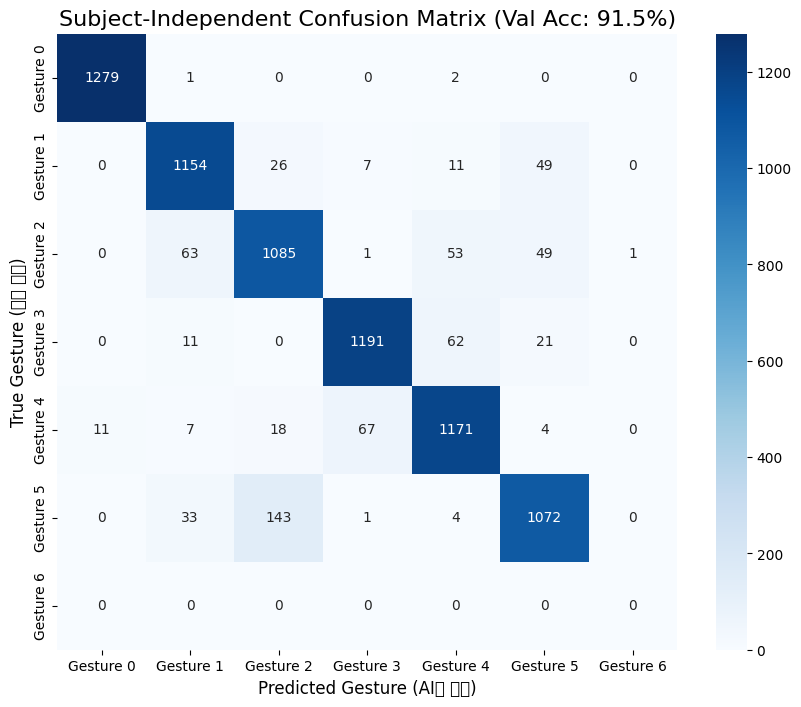

In [10]:
# --- 주피터 셀 6: 최종 평가 리포트 및 혼동 행렬 시각화 ---
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

print("📊 최적 가중치 로드 및 최종 평가 준비 중...")

# 1. 가장 똑똑했던 에포크(8)의 가중치 불러오기
best_model = SubjectIndependentEMGNet(num_classes=7).cuda()
best_model.load_state_dict(torch.load('best_subject_independent_cnn.pth'))
best_model.eval()

all_preds = []
all_labels = []

# 2. 검증 데이터(생판 처음 보는 6명)로 최종 예측 수행
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.cuda(), labels.cuda()
        outputs = best_model(inputs)
        _, predicted = outputs.max(1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 3. 평가 리포트 텍스트 출력
print("\n📝 [분류 성능 상세 리포트]")
print(classification_report(all_labels, all_preds, digits=4))

# 4. 혼동 행렬(Confusion Matrix) 예쁘게 그리기
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[f'Gesture {i}' for i in range(7)],
            yticklabels=[f'Gesture {i}' for i in range(7)])
plt.title('Subject-Independent Confusion Matrix (Val Acc: 91.5%)', fontsize=16)
plt.ylabel('True Gesture (실제 정답)', fontsize=12)
plt.xlabel('Predicted Gesture (AI의 예측)', fontsize=12)
plt.show()